In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('final_dataset.csv')

In [7]:
df.shape

(1461, 12)

In [3]:
df.head(5)

,Date,Month,Year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI
0,1,1,2021,0,5,408.80,442.42,160.61,12.95,2.77,43.19,462
1,2,1,2021,0,6,404.04,561.95,52.85,5.18,2.60,16.43,482
2,3,1,2021,1,7,225.07,239.04,170.95,10.93,1.40,44.29,263
3,4,1,2021,0,1,89.55,132.08,153.98,10.42,1.01,49.19,207
4,5,1,2021,0,2,54.06,55.54,122.66,9.70,0.64,48.88,149


In [4]:
def classificacao_aqi(aqi:int):
    if aqi <= 50: return "Bom"
    elif aqi <= 100: return "Adequado"
    elif aqi <= 150: return "Moderado"
    elif aqi <= 200: return "Ruim"
    elif aqi <= 300: return "Muito ruim"
    else: return "Morte"

In [8]:
df["AQI CLASS"] = df["AQI"].apply(classificacao_aqi)

In [9]:
df.head(5)

,Date,Month,Year,Holidays_Count,Days,PM2.5,PM10,NO2,SO2,CO,Ozone,AQI,AQI CLASS
0,1,1,2021,0,5,408.80,442.42,160.61,12.95,2.77,43.19,462,Morte
1,2,1,2021,0,6,404.04,561.95,52.85,5.18,2.60,16.43,482,Morte
2,3,1,2021,1,7,225.07,239.04,170.95,10.93,1.40,44.29,263,Muito ruim
3,4,1,2021,0,1,89.55,132.08,153.98,10.42,1.01,49.19,207,Muito ruim
4,5,1,2021,0,2,54.06,55.54,122.66,9.70,0.64,48.88,149,Moderado


<Axes: xlabel='AQI CLASS'>

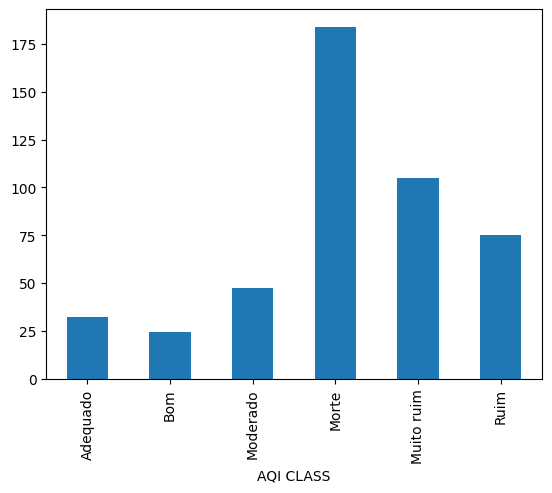

In [14]:
df.groupby("AQI CLASS")["PM2.5"].mean().plot(kind = "bar")

<Axes: xlabel='AQI CLASS'>

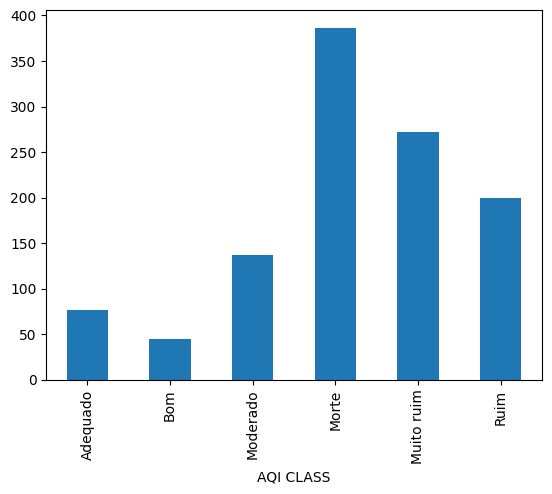

In [15]:
df.groupby("AQI CLASS")["PM10"].mean().plot(kind = "bar")

<Axes: xlabel='AQI CLASS'>

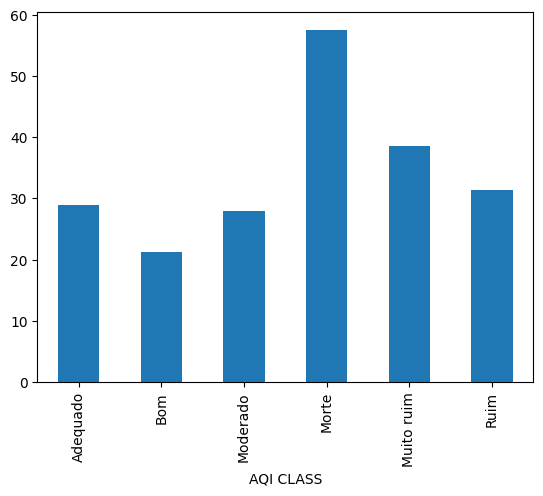

In [16]:
df.groupby("AQI CLASS")["NO2"].mean().plot(kind = "bar")

<Axes: xlabel='AQI CLASS'>

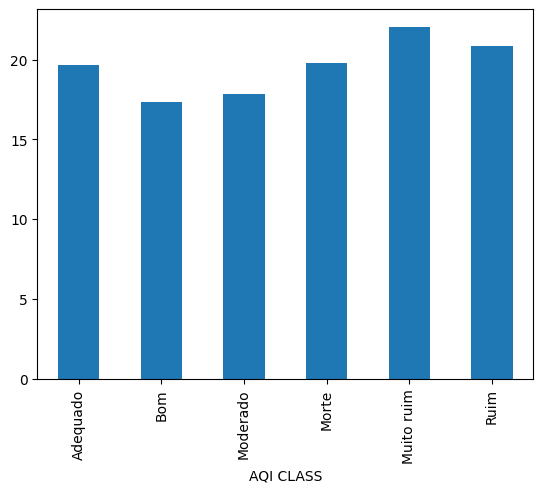

In [17]:
df.groupby("AQI CLASS")["SO2"].mean().plot(kind = "bar")

<Axes: xlabel='AQI CLASS'>

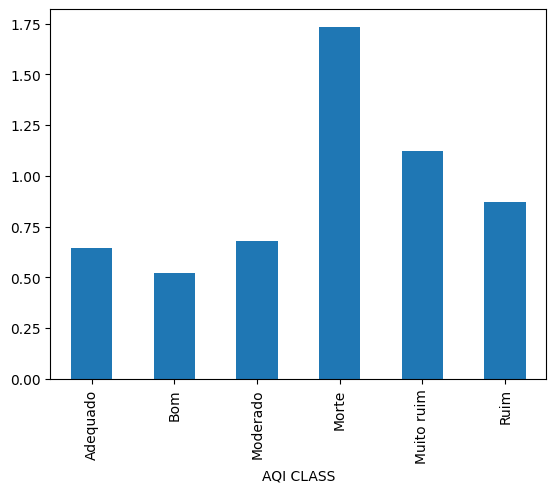

In [18]:
df.groupby("AQI CLASS")["CO"].mean().plot(kind = "bar")

<Axes: xlabel='AQI CLASS'>

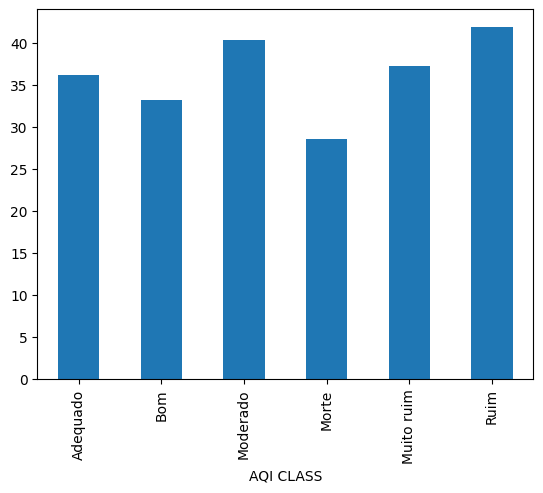

In [19]:
df.groupby("AQI CLASS")["Ozone"].mean().plot(kind = "bar")

<Axes: >

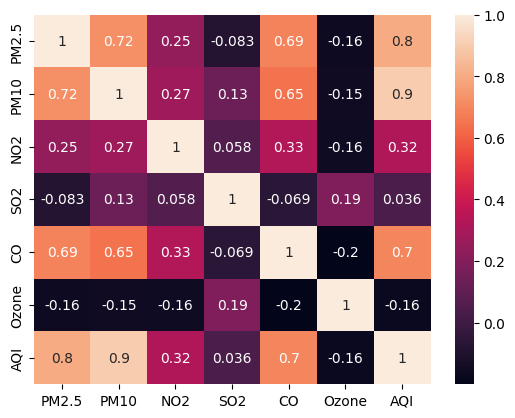

In [25]:
sns.heatmap(df[["PM2.5", "PM10", "NO2", "SO2", "CO", "Ozone", "AQI"]].corr(),
            annot=True)

In [29]:
df[df["PM2.5"] > 800]["PM2.5"] = 0

/tmp/ipykernel_114850/4010565596.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[df["PM2.5"] > 800]["PM2.5"] = 0


In [30]:
df.loc[df["PM2.5"] > 800, "PM2.5"] = 0

In [32]:
df.columns

Index(['Date', 'Month', 'Year', 'Holidays_Count', 'Days', 'PM2.5', 'PM10',
       'NO2', 'SO2', 'CO', 'Ozone', 'AQI', 'AQI CLASS'],
      dtype='object')

<Axes: xlabel='Month', ylabel='PM2.5'>

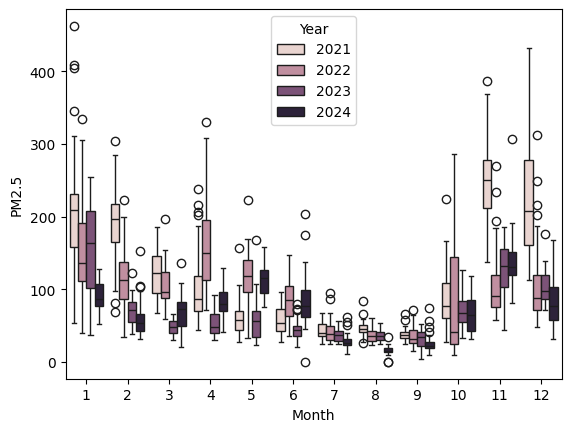

In [35]:
sns.boxplot(data=df, x = 'Month', y = "PM2.5", hue = "Year")

In [34]:
df['Year'].unique()

array([2021, 2022, 2023, 2024])